In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures


In [42]:
def mse(y, y_hat):
    loss = np.mean((y - y_hat)**2)
    return loss

In [43]:
def mae(y, y_hat):
    loss = np.mean(np.abs(y - y_hat))
    return loss

In [44]:
def r2(y, y_hat):
    return 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)

In [45]:
def linear_regression(x,w):
    y_hat= x@ w
    return y_hat

In [46]:
df=pd.read_csv('auto-train-multi.csv')

train_set=np.array(df)
x_train=train_set[ : , :-1]
y_train=train_set[ : ,-1: ]
x_train.shape, y_train.shape

((352, 6), (352, 1))

In [47]:
df=pd.read_csv('auto-test-multi.csv')

test_set=np.array(df)
x_test=test_set[ : , :-1]
y_test=test_set[ : ,-1: ]
x_test.shape, y_test.shape

((40, 6), (40, 1))

In [48]:
df.head()

,cylinders,displacement,horsepower,weight,acceleration,year,mpg
0,1.0,0.813953,0.673913,0.552878,0.119048,0.00,0.159574
1,0.2,0.054264,0.135870,0.088460,0.357143,0.75,0.609043
2,1.0,0.857881,1.000000,0.755600,0.089286,0.25,0.186170
3,0.2,0.095607,0.130435,0.152254,0.410714,0.75,0.678191
4,0.6,0.341085,0.211957,0.276155,0.476191,0.00,0.319149


In [49]:
poly = PolynomialFeatures(degree=2)  

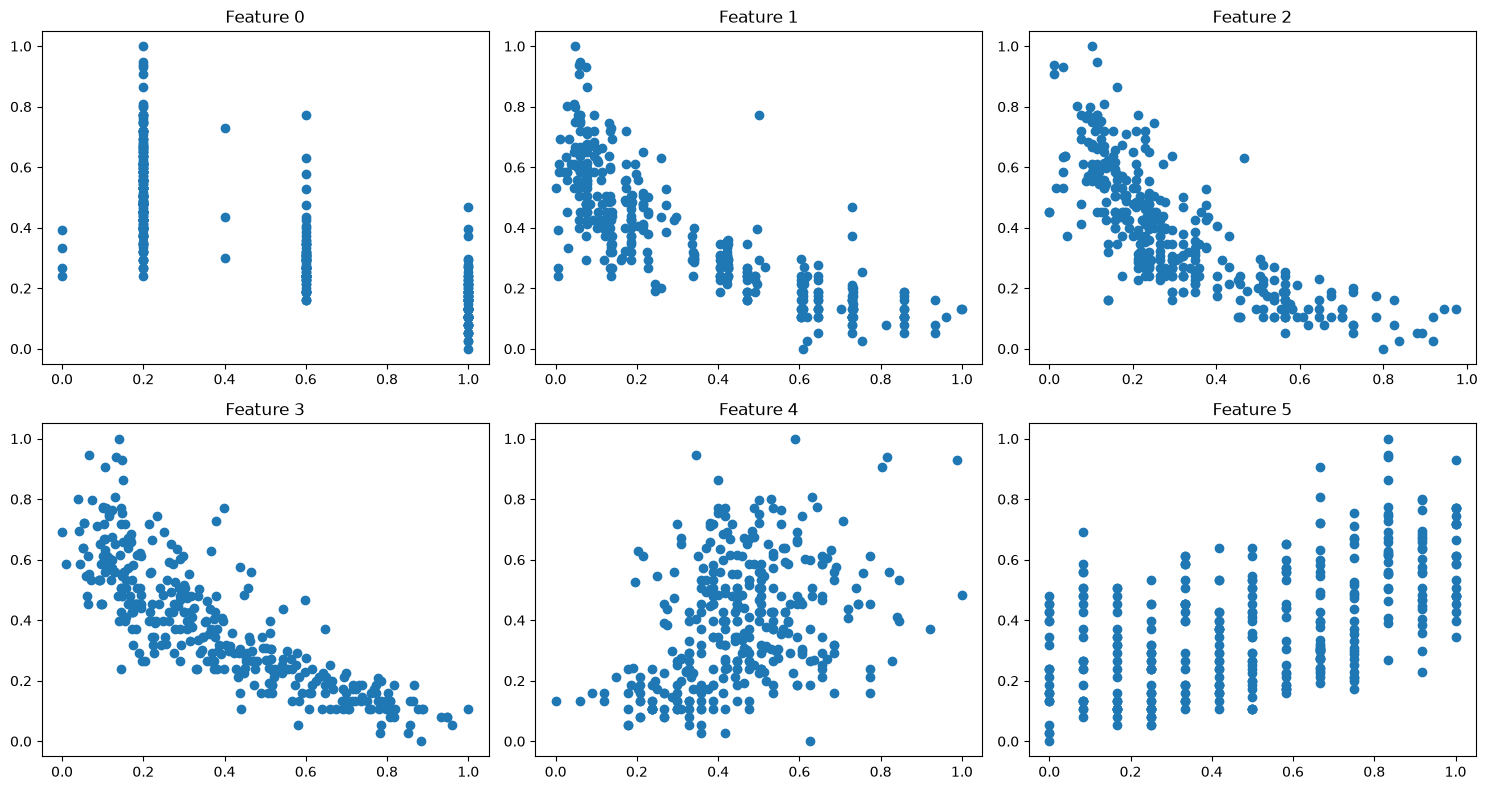

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))


axes = axes.flatten() 

for i in range(x_train.shape[1]):
    axes[i].scatter(x_train[:, i], y_train)
    axes[i].set_title(f"Feature {i}")

plt.tight_layout()
plt.show()

In [51]:
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)
x_train_poly.shape, x_test_poly.shape

((352, 28), (40, 28))

In [52]:
w = np.linalg.inv(x_train_poly.T @ x_train_poly) @ x_train_poly.T @ y_train
w.shape

(28, 1)

In [53]:
y_hat=linear_regression(x_train_poly,w)
y_hat.shape

(352, 1)

In [54]:
y_hat_test=linear_regression(x_test_poly,w)
y_hat_test.shape


(40, 1)

In [55]:
mae(y_test,y_hat_test)

np.float64(0.04477733465254523)

In [56]:
r2(y_test,y_hat_test)

np.float64(0.9310100095802845)

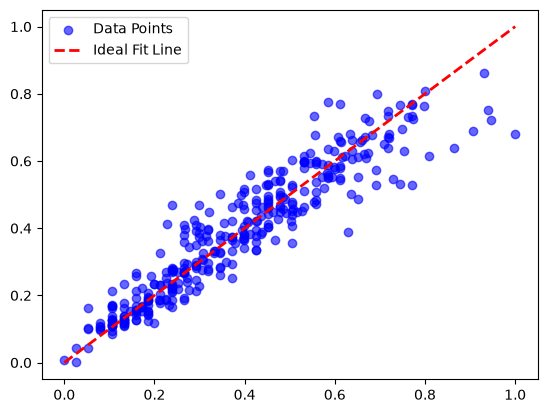

In [57]:
plt.scatter(y_train, y_hat, color='blue', alpha=0.6, label='Data Points')

min_val = min(y_train.min(), y_hat.min())
max_val = max(y_train.max(), y_hat.max())


plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit Line')

plt.legend()
plt.show()
